In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import math
import sys
import os
from pathlib import Path

project_root = Path.cwd().parent.parent
project_root_str = str(project_root)

if project_root_str not in sys.path:
    sys.path.insert(0, project_root_str)

os.chdir(project_root_str)

## The objective of this notebook is to understand how Minutes work
### What leads to a players minutes
- Role
- Health/status
- opponent matchup
- game script (spread, pace, blowout risk)
- coach tendencies
- recent performance


In [45]:
df = pd.read_csv('data/processed/training/PTS_TRAIN_26.csv').sort_values(by='GAME_DATE')
df.head()

C:\Users\alexg\AppData\Local\Temp\ipykernel_39752\2569267919.py:1: DtypeWarning: Columns (33) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('data/processed/training/PTS_TRAIN_26.csv').sort_values(by='GAME_DATE')


,Unnamed: 0,PLAYER_NAME,PLAYER_ID,MATCHUP,TEAM_ABBREVIATION,TEAM_ID,OPP_ABBREVIATION,HOME_GAME,GAME_ID,GAME_DATE,...,REB_AVG_TO_DATE,OREB_AVG_TO_DATE,DREB_AVG_TO_DATE,TOV_AVG_TO_DATE,PTS_OFF_TOV_AVG_TO_DATE,PTS_2ND_CHANCE_AVG_TO_DATE,PTS_FB_AVG_TO_DATE,PTS_PAINT_AVG_TO_DATE,PACE_AVG_TO_DATE,GAMES_PLAYED_TO_DATE
3463,3463,Gary Payton II,1627780,GSW @ LAL,GSW,1610612744,LAL,0,22500002,2025-10-21,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
12289,12289,Jabari Smith Jr.,1631095,HOU @ OKC,HOU,1610612745,OKC,0,22500001,2025-10-21,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
14800,14800,Amen Thompson,1641708,HOU @ OKC,HOU,1610612745,OKC,0,22500001,2025-10-21,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
6061,6061,Jarred Vanderbilt,1629020,LAL vs. GSW,LAL,1610612747,GSW,1,22500002,2025-10-21,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1948,1948,Marcus Smart,203935,LAL vs. GSW,LAL,1610612747,GSW,1,22500002,2025-10-21,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0


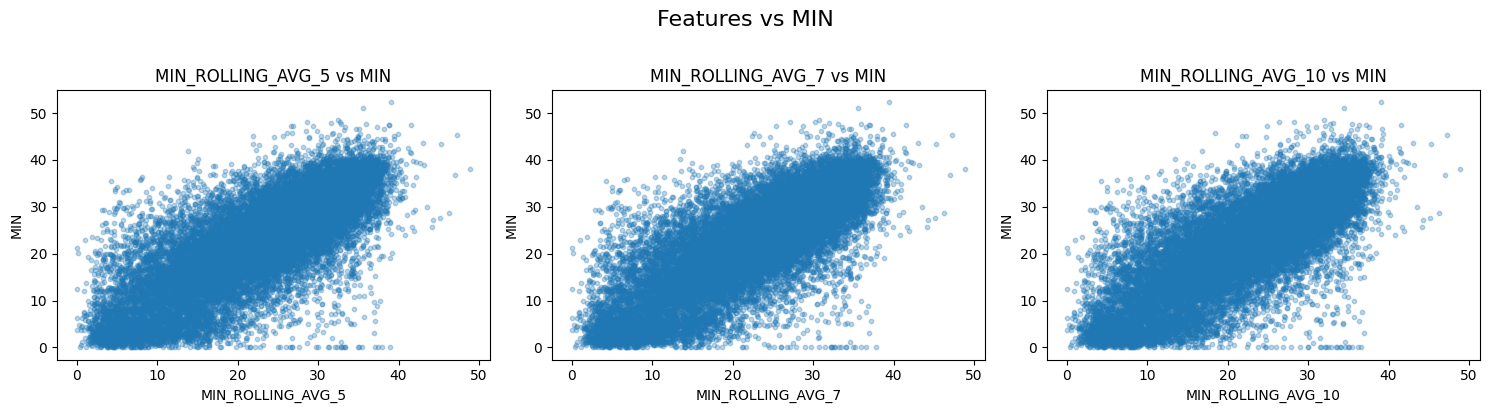

In [11]:
# df["MIN"] = df["MIN"].apply(lambda x: int(x.split(":")[0]) + int(x.split(":")[1])/60)

target = "MIN"
features = ['MIN_ROLLING_AVG_5', 'MIN_ROLLING_AVG_7', 'MIN_ROLLING_AVG_10']

cols = 3
rows = math.ceil(len(features) / cols)

fig, axes = plt.subplots(rows, cols, figsize=(15, rows * 4))
axes = axes.flatten()

for i, feature in enumerate(features):
    axes[i].scatter(df[feature], df[target], alpha=0.3, s=10)
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel(target)
    axes[i].set_title(f"{feature} vs {target}")

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle(f"Features vs {target}", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

In [38]:
hoopers = df.groupby('PLAYER_NAME')['MIN'].mean().round(1).sort_values(ascending=False).head(15)
names = hoopers.index.tolist()


In [50]:
for name in names:
    data = df[df['PLAYER_NAME'] == name]
    print(f"{name} | Minutes Avg: {data['MIN'].mean().round(3)} | Minutes STD: {data['MIN'].std().round(3)} | PTS Avg: {data['PTS'].mean().round(3)}")

Tyrese Maxey | Minutes Avg: 38.26 | Minutes STD: 4.985 | PTS Avg: 28.967
Amen Thompson | Minutes Avg: 36.455 | Minutes STD: 5.671 | PTS Avg: 17.27
Kevin Durant | Minutes Avg: 35.803 | Minutes STD: 6.579 | PTS Avg: 25.597
Luka Dončić | Minutes Avg: 35.495 | Minutes STD: 5.063 | PTS Avg: 32.509
Trey Murphy III | Minutes Avg: 35.387 | Minutes STD: 3.67 | PTS Avg: 22.086
Anthony Edwards | Minutes Avg: 35.182 | Minutes STD: 6.23 | PTS Avg: 29.375
VJ Edgecombe | Minutes Avg: 35.126 | Minutes STD: 5.524 | PTS Avg: 15.414
Cade Cunningham | Minutes Avg: 34.994 | Minutes STD: 5.064 | PTS Avg: 25.105
James Harden | Minutes Avg: 35.007 | Minutes STD: 4.828 | PTS Avg: 24.286
Jalen Johnson | Minutes Avg: 34.943 | Minutes STD: 5.932 | PTS Avg: 22.776
Jamal Murray | Minutes Avg: 34.58 | Minutes STD: 6.494 | PTS Avg: 25.115
Nikola Jokić | Minutes Avg: 34.587 | Minutes STD: 4.874 | PTS Avg: 28.64
Keegan Murray | Minutes Avg: 34.483 | Minutes STD: 8.386 | PTS Avg: 13.957
Paolo Banchero | Minutes Avg: 34.